# Vision Transformer Notebook

This notebook compares a CNN and a Vision Transformer on CIFAR-10.

In [1]:
%pip install torch torchvision matplotlib seaborn scikit-learn

## Step 1: Install Dependencies

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import accuracy_score, confusion_matrix


## Step 2: Import Libraries

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


## Step 3: Select Device

In [4]:
def get_data(batch_size=128):

    train_tf = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
    ])

    test_tf = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
    ])

    train_set = torchvision.datasets.CIFAR10(
        root="./data", train=True, download=True, transform=train_tf
    )

    test_set = torchvision.datasets.CIFAR10(
        root="./data", train=False, download=True, transform=test_tf
    )

    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False)

    classes = train_set.classes

    return train_loader, test_loader, classes


train_loader, test_loader, classes = get_data()

100%|██████████| 170M/170M [00:03<00:00, 43.4MB/s]


## Step 4: Load CIFAR-10 Data

In [5]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Flatten(),
            nn.Linear(256*8*8, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        return self.net(x)

## Step 5: Define the CNN Model

In [6]:
class PatchEmbedding(nn.Module):
    def __init__(self, patch_size=4, embed_dim=128):
        super().__init__()
        self.proj = nn.Conv2d(3, embed_dim, patch_size, patch_size)

    def forward(self, x):
        x = self.proj(x)
        x = x.flatten(2).transpose(1,2)
        return x


class ViT(nn.Module):
    def __init__(self, num_classes=10, embed_dim=128, num_heads=4, depth=4):
        super().__init__()

        self.patch_embed = PatchEmbedding()

        self.cls_token = nn.Parameter(torch.zeros(1,1,embed_dim))
        self.pos_embed = nn.Parameter(torch.randn(1, 1 + 64, embed_dim))

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            batch_first=True
        )

        self.transformer = nn.TransformerEncoder(encoder_layer, depth)

        self.head = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, num_classes)
        )

    def forward(self, x):
        B = x.shape[0]

        x = self.patch_embed(x)

        cls = self.cls_token.expand(B, -1, -1)
        x = torch.cat([cls, x], dim=1)

        x = x + self.pos_embed
        x = self.transformer(x)

        return self.head(x[:,0])

## Step 6: Define the Vision Transformer

In [7]:
def train(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0.0

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


## Step 7: Training and Evaluation Helpers

In [8]:
def evaluate(model, loader, criterion=None):
    model.eval()
    preds, labels = [], []
    total_loss = 0.0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out = model(x)

            if criterion is not None:
                total_loss += criterion(out, y).item()

            pred = torch.argmax(out, dim=1).cpu().numpy()
            preds.extend(pred)
            labels.extend(y.cpu().numpy())

    acc = accuracy_score(labels, preds)
    avg_loss = total_loss / len(loader) if criterion is not None else None
    return acc, avg_loss, preds, labels


In [9]:
def run(model, name, epochs=10):

    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=3e-4)
    loss_fn = nn.CrossEntropyLoss()

    train_losses = []
    val_losses = []
    val_accs = []

    for epoch in range(epochs):
        train_loss = train(model, train_loader, optimizer, loss_fn)
        val_acc, val_loss, _, _ = evaluate(model, test_loader, loss_fn)

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        val_accs.append(val_acc)

        print(f"{name} | Epoch {epoch+1}: Train Loss={train_loss:.4f}, Val Loss={val_loss:.4f}, Val Acc={val_acc:.4f}")

    return model, train_losses, val_losses, val_accs


In [10]:
cnn = CNN()
vit = ViT()

## Step 8: Create the Models

In [11]:
cnn, cnn_train_loss, cnn_val_loss, cnn_val_acc = run(cnn, "CNN")


CNN | Epoch 1: Train Loss=1.7361, Val Loss=1.3219, Val Acc=0.5037
CNN | Epoch 2: Train Loss=1.3960, Val Loss=1.0718, Val Acc=0.6169
CNN | Epoch 3: Train Loss=1.2730, Val Loss=0.9918, Val Acc=0.6450
CNN | Epoch 4: Train Loss=1.1973, Val Loss=0.9998, Val Acc=0.6542
CNN | Epoch 5: Train Loss=1.1443, Val Loss=0.8729, Val Acc=0.6884
CNN | Epoch 6: Train Loss=1.1061, Val Loss=0.8500, Val Acc=0.6998
CNN | Epoch 7: Train Loss=1.0676, Val Loss=0.8826, Val Acc=0.6900
CNN | Epoch 8: Train Loss=1.0442, Val Loss=0.8047, Val Acc=0.7141
CNN | Epoch 9: Train Loss=1.0170, Val Loss=0.7844, Val Acc=0.7294
CNN | Epoch 10: Train Loss=0.9934, Val Loss=0.7279, Val Acc=0.7456


In [12]:
vit, vit_train_loss, vit_val_loss, vit_val_acc = run(vit, "ViT")


ViT | Epoch 1: Train Loss=1.9666, Val Loss=1.7152, Val Acc=0.3753
ViT | Epoch 2: Train Loss=1.6922, Val Loss=1.5116, Val Acc=0.4535
ViT | Epoch 3: Train Loss=1.5543, Val Loss=1.4407, Val Acc=0.4847
ViT | Epoch 4: Train Loss=1.4673, Val Loss=1.3655, Val Acc=0.5072
ViT | Epoch 5: Train Loss=1.3933, Val Loss=1.3342, Val Acc=0.5231
ViT | Epoch 6: Train Loss=1.3424, Val Loss=1.2536, Val Acc=0.5500
ViT | Epoch 7: Train Loss=1.2987, Val Loss=1.2534, Val Acc=0.5450
ViT | Epoch 8: Train Loss=1.2571, Val Loss=1.1865, Val Acc=0.5711
ViT | Epoch 9: Train Loss=1.2202, Val Loss=1.1589, Val Acc=0.5808
ViT | Epoch 10: Train Loss=1.1825, Val Loss=1.1113, Val Acc=0.5971


## Step 9: Plot Learning Curves

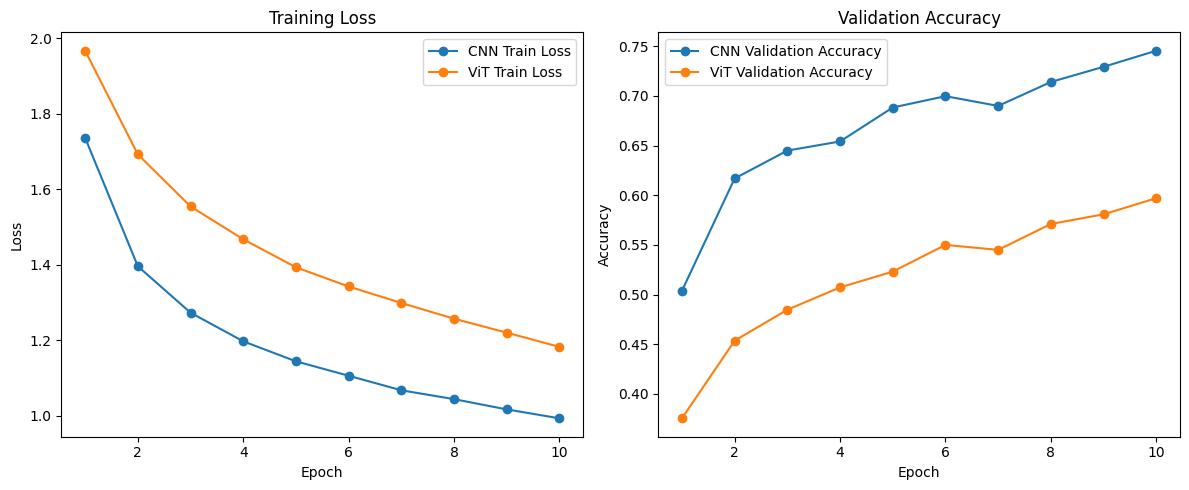

In [13]:
epochs = range(1, len(cnn_val_acc) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, cnn_train_loss, marker="o", label="CNN Train Loss")
plt.plot(epochs, vit_train_loss, marker="o", label="ViT Train Loss")
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, cnn_val_acc, marker="o", label="CNN Validation Accuracy")
plt.plot(epochs, vit_val_acc, marker="o", label="ViT Validation Accuracy")
plt.title("Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()


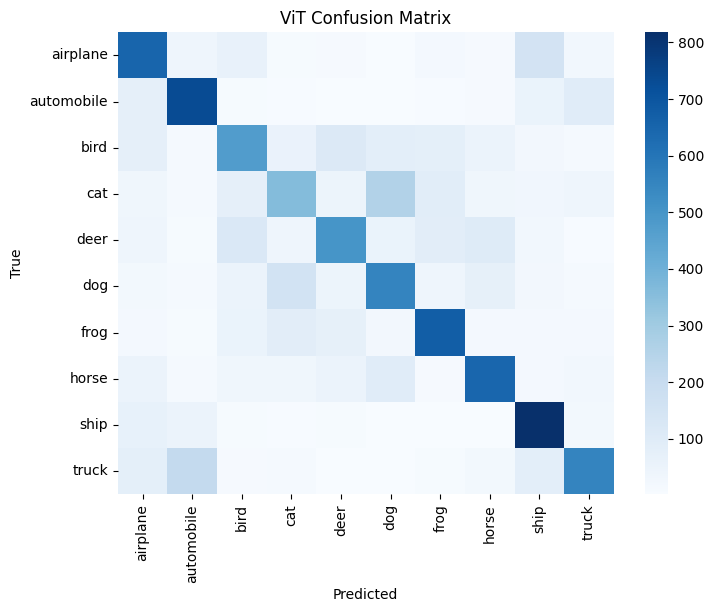

In [14]:
_, _, preds, labels = evaluate(vit, test_loader)

cm = confusion_matrix(labels, preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, cmap="Blues", xticklabels=classes, yticklabels=classes)
plt.title("ViT Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


## Step 10: Show Confusion Matrix